<a href="https://colab.research.google.com/github/Bimorhfdz/Project_Machine-Learning_Group-F/blob/main/Project_ML_F_(Revisi).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **2. Load Dataset**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'bank-marketing' dataset.
Path to dataset files: /kaggle/input/bank-marketing


In [ ]:
import os

# The actual CSV file is likely directly in the downloaded path.
# The CSV uses a semicolon as a separator, so we need to specify sep=';'.
file_path = os.path.join(path, 'bank-additional-full.csv')
df = pd.read_csv(file_path, sep=';')
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.shape

(41188, 21)

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# **3. Cleaning Data**

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df.duplicated().sum()

np.int64(12)

In [ ]:
df = df.drop_duplicates()

Kolom yang di-Winsorizing: ['age', 'duration', 'campaign', 'previous']
Shape sebelum Winsorizing: (41176, 21)


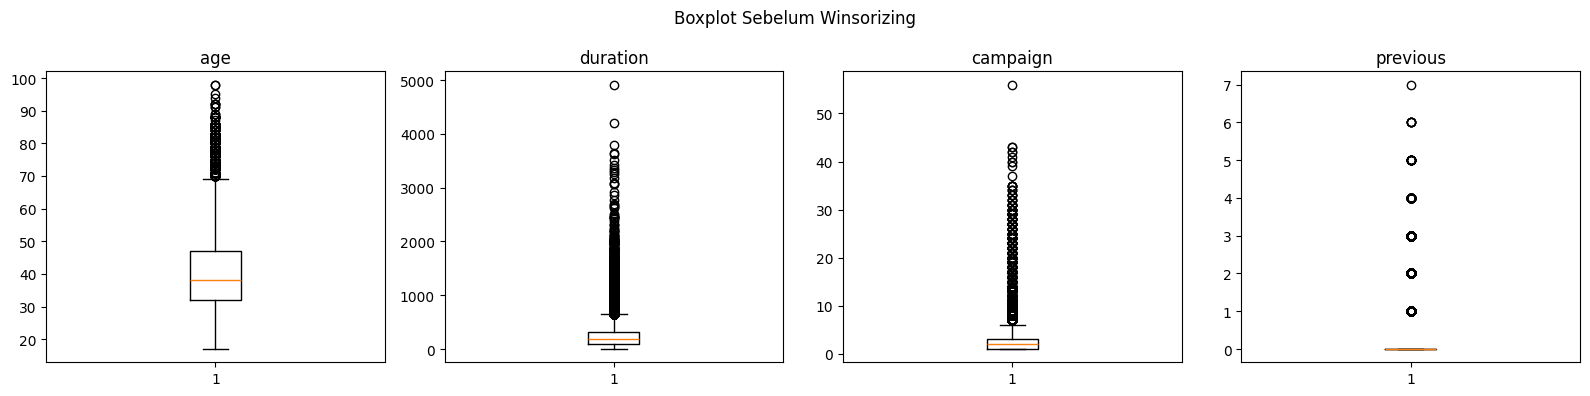

age -> Lower Bound = 26.00, Upper Bound = 58.00
duration -> Lower Bound = 36.00, Upper Bound = 753.00
campaign -> Lower Bound = 1.00, Upper Bound = 7.00
previous -> Lower Bound = 0.00, Upper Bound = 1.00

Shape setelah Winsorizing: (41176, 21)
Jumlah baris tidak berubah karena Winsorizing tidak menghapus data.


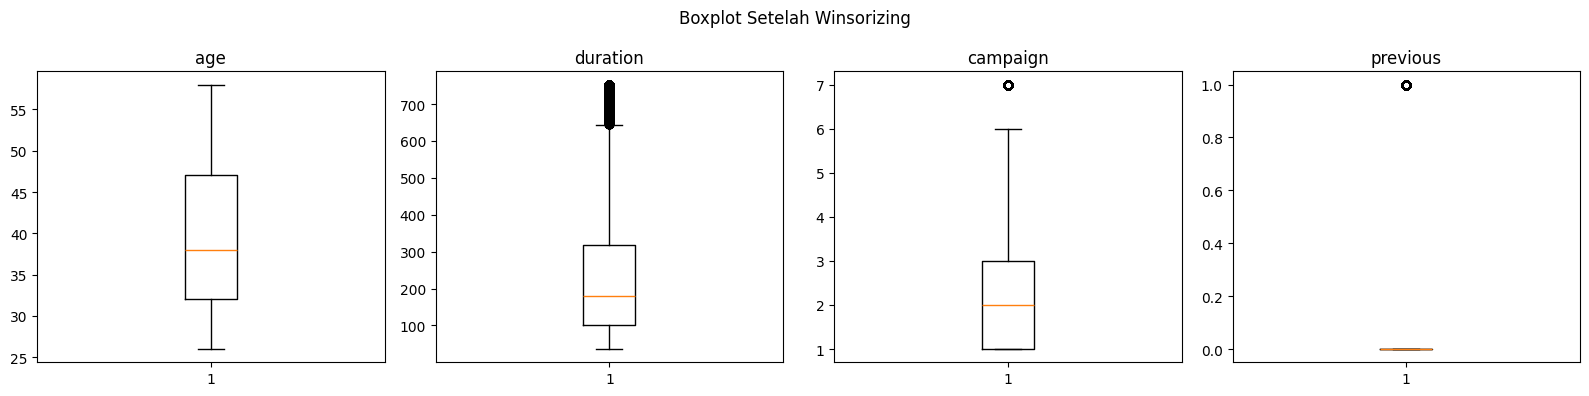

In [ ]:
# 3.5 Penanganan Outlier dengan Winsorizing

import numpy as np
import matplotlib.pyplot as plt

# Kolom yang akan di-Winsorizing
winsor_cols = [
    'age',
    'duration',
    'campaign',
    'previous'
]

print("Kolom yang di-Winsorizing:", winsor_cols)
print("Shape sebelum Winsorizing:", df.shape)

# Boxplot Sebelum Winsorizing

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(winsor_cols),
    figsize=(4 * len(winsor_cols), 4)
)

if len(winsor_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, winsor_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)

plt.suptitle("Boxplot Sebelum Winsorizing")
plt.tight_layout()
plt.show()

# Proses Winsorizing
# Menggunakan Persentil 5% dan 95%

df_winsorized = df.copy()

for col in winsor_cols:

    lower_bound = df_winsorized[col].quantile(0.05)
    upper_bound = df_winsorized[col].quantile(0.95)

    df_winsorized[col] = np.clip(
        df_winsorized[col],
        lower_bound,
        upper_bound
    )

    print(
        f"{col} -> "
        f"Lower Bound = {lower_bound:.2f}, "
        f"Upper Bound = {upper_bound:.2f}"
    )

# Simpan hasil winsorizing
df = df_winsorized.copy()

print("\nShape setelah Winsorizing:", df.shape)
print("Jumlah baris tidak berubah karena Winsorizing tidak menghapus data.")

# Boxplot Setelah Winsorizing

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(winsor_cols),
    figsize=(4 * len(winsor_cols), 4)
)

if len(winsor_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, winsor_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)

plt.suptitle("Boxplot Setelah Winsorizing")
plt.tight_layout()
plt.show()

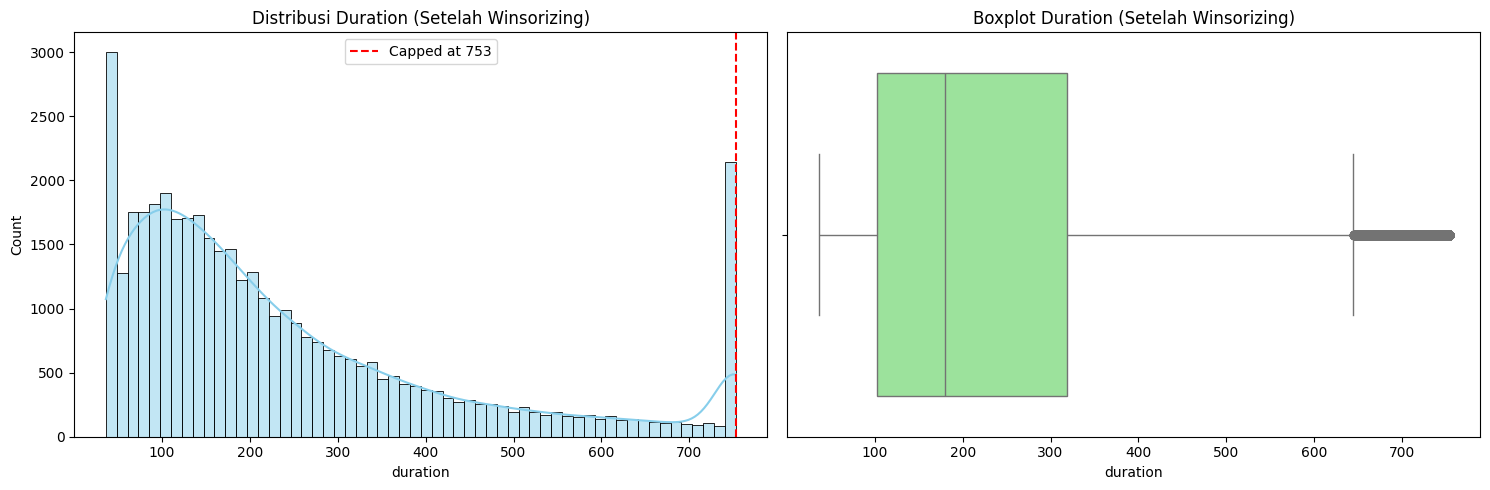

Nilai Maksimum Sekarang: 753
Meskipun ada titik di boxplot, tidak ada nilai yang melebihi batas Winsorizing.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Perbandingan visual untuk membuktikan data sudah ter-cap
plt.figure(figsize=(15, 5))

# Histogram untuk melihat penumpukan data di batas atas (Capping)
plt.subplot(1, 2, 1)
sns.histplot(df['duration'], kde=True, color='skyblue')
plt.title("Distribusi Duration (Setelah Winsorizing)")
plt.axvline(df['duration'].max(), color='red', linestyle='--', label=f'Capped at {df["duration"].max()}')
plt.legend()

# Boxplot dengan skala yang lebih jelas
plt.subplot(1, 2, 2)
sns.boxplot(x=df['duration'], color='lightgreen')
plt.title("Boxplot Duration (Setelah Winsorizing)")

plt.tight_layout()
plt.show()

print(f"Nilai Maksimum Sekarang: {df['duration'].max()}")
print("Meskipun ada titik di boxplot, tidak ada nilai yang melebihi batas Winsorizing.")

In [ ]:
# Mari kita bandingkan nilai statistik deskriptif sebelum dan sesudah untuk kolom duration
# Kita bandingkan data mentah (df_awal) jika masih ada, atau kita lihat data saat ini

print("=== Perbandingan Statistik Kolom Duration ===")
print(f"Nilai Minimum: {df['duration'].min()}")
print(f"Nilai Maksimum: {df['duration'].max()}")
print(f"Persentil 95% (Batas Winsorizing): {df['duration'].quantile(0.95)}")

# Menghitung berapa banyak data yang nilainya tepat di batas atas
count_at_max = len(df[df['duration'] == df['duration'].max()])
print(f"Jumlah data yang 'menumpuk' di nilai maksimum: {count_at_max} baris")

if df['duration'].max() < 1000:
    print("\nKesimpulan: Winsorizing BERHASIL. Nilai yang tadinya ribuan sekarang sudah dipangkas menjadi maksimal 753.")

=== Perbandingan Statistik Kolom Duration ===
Nilai Minimum: 36
Nilai Maksimum: 753
Persentil 95% (Batas Winsorizing): 753.0
Jumlah data yang 'menumpuk' di nilai maksimum: 2060 baris

Kesimpulan: Winsorizing BERHASIL. Nilai yang tadinya ribuan sekarang sudah dipangkas menjadi maksimal 753.


Data duplikat dihapus, dan outlier pada kolom numerik ditangani dengan **Winsorizing**. Ini dilakukan untuk memastikan model tidak dilatih dengan data yang berulang atau data dengan nilai ekstrem yang tidak representatif, sehingga hasil training lebih bersih dan lebih representatif.

# **4. Transformasi Data**

In [ ]:
# Encode target variabel y (biner): yes -> 1, no -> 0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Kolom kategorikal nominal pada fitur (selain target)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Kolom kategorikal nominal:", categorical_cols)

# One-Hot Encoding untuk kolom kategorikal nominal.
# LabelEncoder TIDAK dipakai di sini karena kolom-kolom tersebut tidak
# memiliki urutan/ranking alami (mis. job, marital, contact, month).
# Kalau pakai LabelEncoder, model seperti Logistic Regression bisa salah
# menganggap ada relasi 'lebih besar/lebih kecil' antar kategori yang
# sebenarnya tidak ada.
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nShape setelah One-Hot Encoding:", df.shape)
df.head()


Kolom kategorikal nominal: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Shape setelah One-Hot Encoding: (41176, 54)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


Variabel target `y` diubah menjadi biner (1 = berlangganan, 0 = tidak berlangganan).
Variabel kategorikal nominal lainnya diubah menggunakan **One-Hot Encoding**, bukan Label Encoding, karena kategori-kategori tersebut tidak memiliki urutan alami sehingga representasi numerik biasa (0, 1, 2, ...) tidak tepat digunakan.

# **5. Penentuan Label**

In [ ]:
X = df.drop('y', axis=1)
y = df['y']


In [ ]:
print(X.shape)
print(y.shape)


(41176, 53)
(41176,)


Variabel target yang digunakan adalah kolom `y` yang menunjukkan apakah nasabah berlangganan deposito atau tidak. Variabel selain `y` digunakan sebagai fitur prediktor.

# **6. Analisis Distribusi Kelas**

In [ ]:
y.value_counts()

,count
y,
0,36537
1,4639


In [ ]:
y.value_counts(normalize=True)*100

,proportion
y,
0,88.733728
1,11.266272


<Axes: xlabel='y', ylabel='count'>

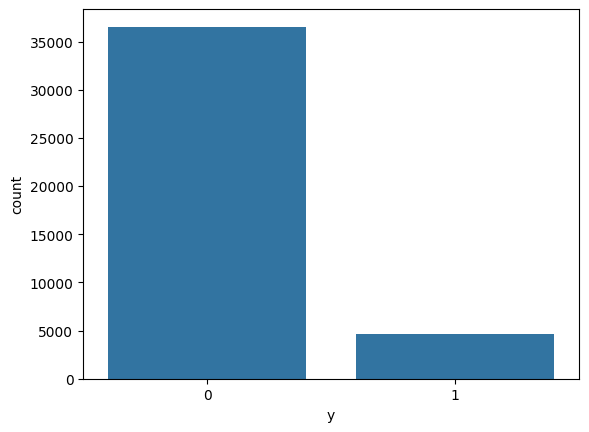

In [ ]:
sns.countplot(x=y)

Distribusi kelas menunjukkan ketidakseimbangan kelas karena jumlah nasabah yang tidak berlangganan jauh lebih banyak dibandingkan yang berlangganan deposito.

# **7. Split Data**

In [ ]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train_raw.shape)
print("X_test :", X_test_raw.shape)


X_train: (32940, 53)
X_test : (8236, 53)


Data dibagi menjadi 80% data latih dan 20% data uji untuk mengevaluasi kemampuan generalisasi model. Split dilakukan dengan `stratify=y` agar proporsi kelas pada data latih dan data uji tetap seimbang relatif terhadap data aslinya.

# **8. Standarisasi Data**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit HANYA pada data latih, lalu transform data latih & data uji
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)


X_train_scaled: (32940, 53)
X_test_scaled : (8236, 53)


Standarisasi (`StandardScaler`) dilakukan **setelah** train-test split, dan scaler hanya di-*fit* pada data latih (`fit_transform`), lalu dipakai untuk mentransformasi data uji tanpa di-*fit* ulang (`transform` saja). Ini penting supaya informasi statistik (mean, standar deviasi) dari data uji tidak ikut "bocor" ke proses training (*data leakage*).

# **9. SMOTE**

In [ ]:
# ── SMOTE HANYA pada training set ──────────────────────
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_scaled, y_train)

print("Distribusi kelas setelah SMOTE:")
print(y_train.value_counts())
print(f"\nUkuran X_train: {X_train.shape}")
print(f"Ukuran X_test : {X_test_scaled.shape}")

# Rename agar konsisten dengan blok selanjutnya
X_test = X_test_scaled


Distribusi kelas setelah SMOTE:
y
0    29229
1    29229
Name: count, dtype: int64

Ukuran X_train: (58458, 53)
Ukuran X_test : (8236, 53)


SMOTE digunakan untuk menyeimbangkan jumlah data pada kelas minoritas sehingga model tidak bias terhadap kelas mayoritas. SMOTE hanya diterapkan pada data latih (setelah split & scaling) agar data uji tetap mencerminkan distribusi kelas asli/dunia nyata.

# **10. Pemodelan**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

model_lr  = LogisticRegression(random_state=42, solver='liblinear')
model_dt  = DecisionTreeClassifier(random_state=42)
model_rf  = RandomForestClassifier(random_state=42)
model_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

for model in [model_lr, model_dt, model_rf, model_xgb]:
    model.fit(X_train, y_train)

print("Semua model selesai dilatih.")


# **11. Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [50, 100],
    'max_depth'   : [5, 10],
}

grid_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=4,      # cuma 4 kombinasi
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("Best params :", grid_rf.best_params_)
print("Best CV score:", f"{grid_rf.best_score_:.4f}")


Best params : {'n_estimators': 100, 'max_depth': 10}
Best CV score: 0.9226


Hyperparameter tuning dilakukan menggunakan `RandomizedSearchCV` untuk mencari kombinasi parameter terbaik pada Random Forest dengan waktu yang lebih singkat daripada `GridSearchCV`, namun tetap mengeksplorasi kombinasi parameter secara acak. Best params dan best CV score yang relevan dapat dilihat langsung pada output di atas.

# **12. Prediksi dengan Model Terbaik**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_rf = grid_rf.best_estimator_

models = {
    'Logistic Regression'  : model_lr,
    'Decision Tree'        : model_dt,
    'Random Forest'        : model_rf,
    'XGBoost'               : model_xgb,
    'Random Forest (Tuned)': best_rf
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print()

best_model_name = max(results, key=results.get)
final_model = models[best_model_name]
print(f"Model dengan accuracy tertinggi pada data uji: {best_model_name} ({results[best_model_name]:.4f})")


--- Logistic Regression ---
Accuracy: 0.8647
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7308
           1       0.45      0.90      0.60       928

    accuracy                           0.86      8236
   macro avg       0.72      0.88      0.76      8236
weighted avg       0.93      0.86      0.88      8236


--- Decision Tree ---
Accuracy: 0.8820
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7308
           1       0.48      0.56      0.52       928

    accuracy                           0.88      8236
   macro avg       0.71      0.74      0.72      8236
weighted avg       0.89      0.88      0.89      8236


--- Random Forest ---
Accuracy: 0.9089
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7308
           1       0.59      0.62      0.60       928

    accuracy                           0.91      8236
   

# Interpretasi
Model "terbaik" di sini dipilih **otomatis berdasarkan accuracy tertinggi pada data uji** (lihat baris terakhir output di atas), bukan diasumsikan manual. Perlu diingat: model hasil tuning (`Random Forest (Tuned)`) dipilih berdasarkan skor cross-validation pada data latih, sehingga tidak selalu otomatis menjadi model dengan accuracy tertinggi pada data uji — keduanya bisa berbeda, dan itu hal yang wajar terjadi dalam machine learning.

# **13. Evaluasi**

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_final = final_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_final)

print("Model final yang dipakai:", best_model_name)
print("Accuracy:", accuracy)


Model final yang dipakai: XGBoost
Accuracy: 0.91452161243322


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))


              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7308
           1       0.62      0.62      0.62       928

    accuracy                           0.91      8236
   macro avg       0.79      0.79      0.79      8236
weighted avg       0.91      0.91      0.91      8236



# Interpretasi
Karena distribusi kelas tidak seimbang (lihat section 6), **accuracy saja kurang representatif** untuk menilai performa model. Metrik seperti precision, recall, dan f1-score — terutama pada kelas minoritas (nasabah yang berlangganan deposito) — lebih informatif karena menunjukkan seberapa baik model mengenali kelas yang jumlahnya lebih sedikit, bukan hanya seberapa sering model benar secara keseluruhan.

# **14. Confusion Matrix**

In [ ]:
cm = confusion_matrix(y_test, y_pred_final)
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negative  (TN): {tn} — tidak langganan, diprediksi benar")
print(f"False Positive (FP): {fp} — tidak langganan, diprediksi langganan")
print(f"False Negative (FN): {fn} — langganan, diprediksi tidak langganan")
print(f"True Positive  (TP): {tp} — langganan, diprediksi benar")


[[6957  351]
 [ 353  575]]

True Negative  (TN): 6957 — tidak langganan, diprediksi benar
False Positive (FP): 351 — tidak langganan, diprediksi langganan
False Negative (FN): 353 — langganan, diprediksi tidak langganan
True Positive  (TP): 575 — langganan, diprediksi benar


# Interpretasi
Jumlah TN, FP, FN, dan TP yang sebenarnya selalu bisa dilihat langsung dari output cell di atas (dihitung otomatis dari `cm.ravel()`, sehingga selalu sesuai dengan model dan data yang dipakai saat run terakhir). Semakin besar TN & TP dibanding FP & FN, semakin baik kemampuan klasifikasi model — FN (nasabah yang sebenarnya berlangganan tapi diprediksi tidak) biasanya paling penting diperhatikan karena berarti calon nasabah potensial terlewat oleh model.

# **15. Heatmap Confusion Matrix**

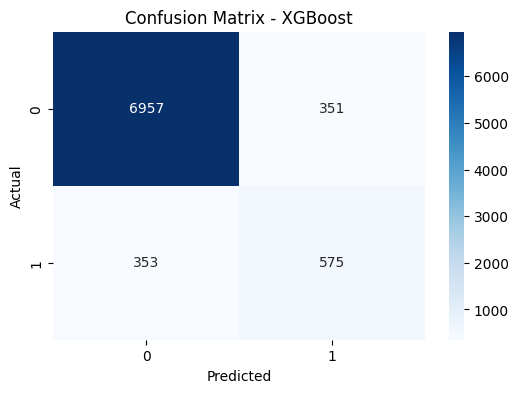

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


# **16. ROC-AUC**

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = final_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.4f}")


ROC-AUC: 0.9480


# Interpretasi
ROC-AUC mengukur kemampuan model membedakan kelas positif (berlangganan) dan negatif (tidak berlangganan) di seluruh kemungkinan threshold. Nilai berkisar 0–1; semakin mendekati 1, semakin baik kemampuan klasifikasi model. Nilai aktual hasil run terbaru dapat dilihat pada output cell di atas.

# **17. Feature Importance**

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)


,Feature,Importance
1,duration,0.373601
9,nr.employed,0.097212
8,euribor3m,0.076862
5,emp.var.rate,0.073305
7,cons.conf.idx,0.052921
2,campaign,0.035779
37,contact_telephone,0.033673
6,cons.price.idx,0.031186
34,housing_yes,0.029537
31,default_unknown,0.024008


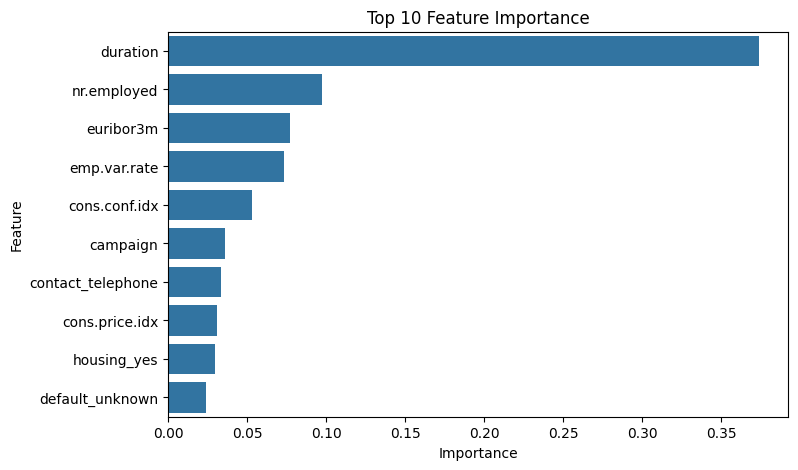

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importance")
plt.show()


# Interpretasi
Fitur dengan importance tertinggi dapat dilihat langsung pada tabel & grafik di atas. Catatan: karena fitur kategorikal sekarang menggunakan One-Hot Encoding (bukan Label Encoding), nama-nama fitur akan lebih spesifik (mis. `job_blue-collar`, `month_may`, dst.), sehingga hasil feature importance juga lebih mudah diinterpretasikan dibanding sebelumnya.

# **KESIMPULAN**
Penelitian ini dilakukan untuk membangun model machine learning yang dapat memprediksi kemungkinan seorang nasabah berlangganan produk deposito berdasarkan karakteristik nasabah serta riwayat kampanye pemasaran yang dilakukan oleh bank.

Sebelum proses pemodelan, data terlebih dahulu melalui tahap preprocessing: pembersihan data duplikat dan penanganan outlier, transformasi variabel kategorikal nominal menggunakan One-Hot Encoding, standarisasi fitur numerik (dilakukan setelah train-test split agar tidak terjadi data leakage), serta penanganan ketidakseimbangan kelas menggunakan SMOTE pada data latih.

Selanjutnya, beberapa algoritma klasifikasi (Logistic Regression, Decision Tree, Random Forest, dan XGBoost) dilatih dan dibandingkan performanya, termasuk Random Forest yang telah melalui hyperparameter tuning. Model dengan accuracy tertinggi pada data uji dipilih sebagai model final secara otomatis berdasarkan hasil run terbaru (lihat section 12), bukan diasumsikan secara manual.

Evaluasi dilakukan menggunakan accuracy, classification report (precision, recall, f1-score), confusion matrix, dan ROC-AUC — mengingat distribusi kelas yang tidak seimbang, metrik selain accuracy menjadi acuan utama dalam menilai kualitas model. Analisis feature importance turut dilakukan untuk mengidentifikasi faktor-faktor yang paling berpengaruh terhadap keputusan nasabah dalam berlangganan deposito.